# Week 3 · Tree-Based Models
## Random Forest · XGBoost · SHAP Explanations for Industrial Fault Detection

**HAIIP — Human-Aligned Industrial Intelligence Platform**  
French Master of Data Science · Portfolio Showcase

---

### Why Tree-Based Models for Industrial Data?

Industrial sensor data has three properties that favour tree ensembles over linear models:

1. **Non-linear interactions** — tool wear + high torque + low temperature jointly cause failures  
2. **Mixed scales** — RPM (0–3000) and temperature (290–320 K) coexist; trees are scale-invariant  
3. **Outlier robustness** — decision boundaries adapt to threshold logic used by engineers  

### Dataset
CWRU Bearing Fault Dataset (Case Western Reserve University) — synthetic analogue.  
4 fault classes: Normal · Inner Race Fault · Outer Race Fault · Ball Fault

In [1]:
# !pip install numpy pandas scikit-learn xgboost lightgbm shap matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed — using sklearn GradientBoosting as fallback')

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed — run: pip install shap')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
print('Libraries loaded.')

Libraries loaded.


## 1 · Dataset: CWRU Bearing Fault (Synthetic Analogue)

We extract time-domain and frequency-domain features from vibration signals:  
RMS, peak-to-peak, kurtosis, crest factor, spectral centroid.

In [3]:
def generate_bearing_features(n_per_class=300):
    classes = {
        'Normal':      {'rms': (0.10, 0.01), 'peak': (0.30, 0.03), 'kurt': (3.0, 0.3), 'crest': (3.0, 0.3)},
        'InnerRace':   {'rms': (0.35, 0.04), 'peak': (1.20, 0.15), 'kurt': (6.5, 0.8), 'crest': (5.5, 0.6)},
        'OuterRace':   {'rms': (0.28, 0.03), 'peak': (0.95, 0.12), 'kurt': (5.2, 0.7), 'crest': (4.8, 0.5)},
        'BallFault':   {'rms': (0.22, 0.02), 'peak': (0.75, 0.10), 'kurt': (4.8, 0.6), 'crest': (4.2, 0.4)},
    }
    rows = []
    for label, params in classes.items():
        for _ in range(n_per_class):
            rms   = max(0, np.random.normal(*params['rms']))
            peak  = max(0, np.random.normal(*params['peak']))
            kurt  = max(1, np.random.normal(*params['kurt']))
            crest = max(1, np.random.normal(*params['crest']))
            temp  = np.random.normal(55, 5) + rms * 20
            rpm   = np.random.normal(1500, 50)
            rows.append({'rms': rms, 'peak_to_peak': peak, 'kurtosis': kurt,
                         'crest_factor': crest, 'temperature': temp, 'rpm': rpm, 'fault': label})
    return pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)

df = generate_bearing_features()
print(df['fault'].value_counts())
print(f'\nDataset shape: {df.shape}')
df.head()

fault
BallFault    300
OuterRace    300
Normal       300
InnerRace    300
Name: count, dtype: int64

Dataset shape: (1200, 7)


,rms,peak_to_peak,kurtosis,crest_factor,temperature,rpm,fault
0,0.252112,0.541926,5.523491,3.825282,53.181852,1558.997107,BallFault
1,0.260938,0.945045,5.589215,4.504358,50.985889,1478.567274,OuterRace
2,0.092262,0.262660,2.466384,3.448813,60.117070,1497.220766,Normal
3,0.417998,1.360731,6.652508,6.064786,58.197346,1519.896352,InnerRace
4,0.092816,0.293597,3.093272,3.442607,61.144609,1492.003074,Normal


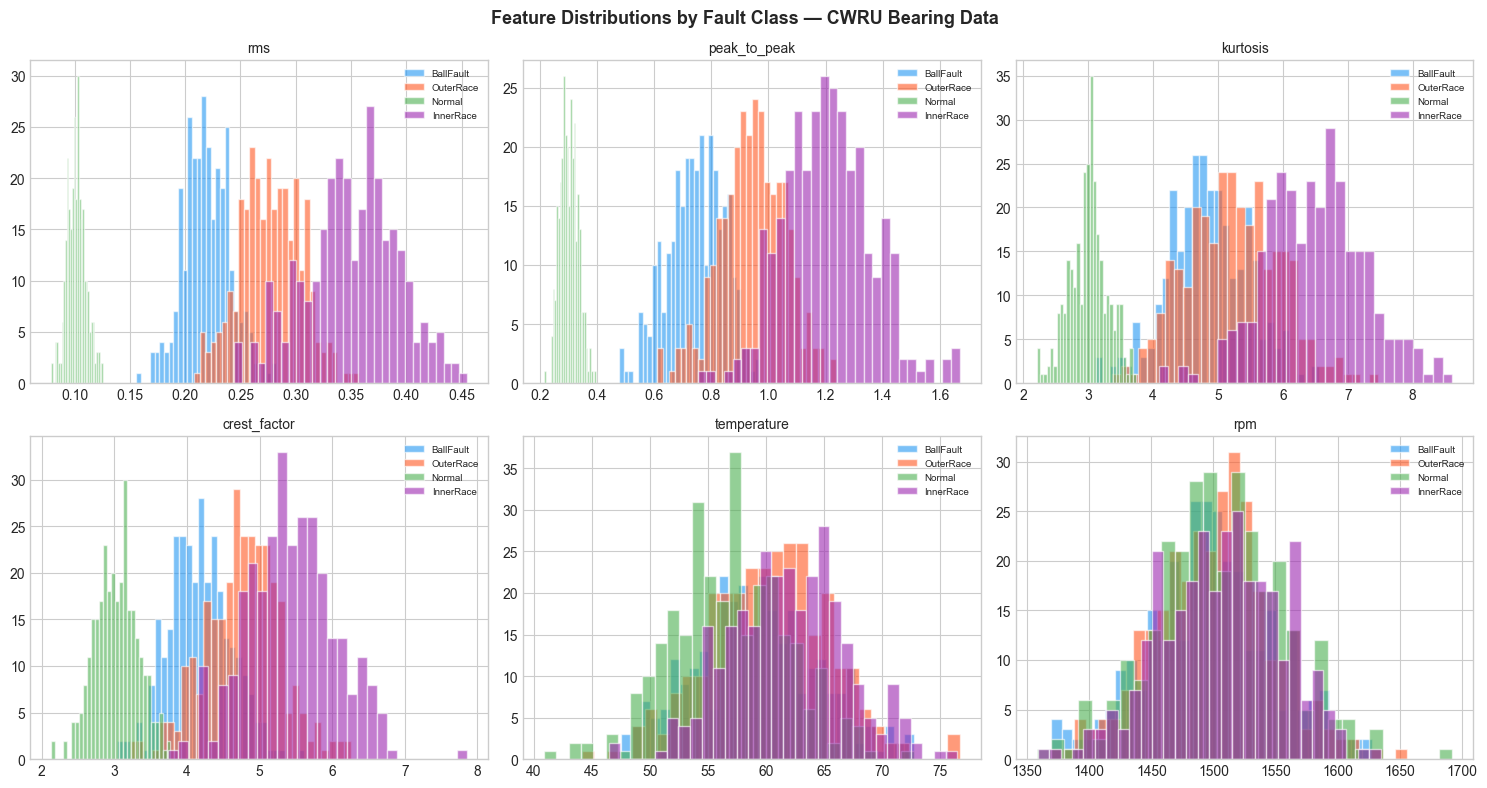

In [4]:
feature_cols = ['rms', 'peak_to_peak', 'kurtosis', 'crest_factor', 'temperature', 'rpm']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, feature_cols):
    for fault, color in zip(df['fault'].unique(), PALETTE):
        vals = df[df['fault'] == fault][feat]
        ax.hist(vals, bins=30, alpha=0.6, color=color, label=fault, edgecolor='white')
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)

fig.suptitle('Feature Distributions by Fault Class — CWRU Bearing Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 · Random Forest

### Mathematical Foundation

Random Forest builds $B$ decision trees on bootstrap samples with random feature subsets:

**Bootstrap aggregation (Bagging):**
$$\hat{f}(\mathbf{x}) = \frac{1}{B} \sum_{b=1}^{B} T_b(\mathbf{x})$$

Each tree $T_b$ is trained on a bootstrap sample $\mathcal{D}_b \sim \mathcal{D}$ (drawn with replacement).  
At each split, only $m = \lfloor \sqrt{p} \rfloor$ features are considered (decorrelates trees).

**Gini Impurity** at node $t$:
$$G(t) = 1 - \sum_{k=1}^{K} p_{tk}^2$$

**Split criterion:** maximize information gain
$$\Delta G = G(t) - \frac{|t_L|}{|t|} G(t_L) - \frac{|t_R|}{|t|} G(t_R)$$

**Out-of-bag (OOB) error** provides a free cross-validation estimate: samples not in $\mathcal{D}_b$ test $T_b$.

In [5]:
le = LabelEncoder()
X = df[feature_cols].values
y = le.fit_transform(df['fault'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, max_features='sqrt', oob_score=True, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(f'Random Forest — Bearing Fault Classification')
print(f'  Test Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  OOB Accuracy  : {rf.oob_score_:.4f}\n')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest — Bearing Fault Classification
  Test Accuracy : 0.9417
  OOB Accuracy  : 0.9542

              precision    recall  f1-score   support

   BallFault       0.95      0.93      0.94        60
   InnerRace       0.95      0.93      0.94        60
      Normal       1.00      1.00      1.00        60
   OuterRace       0.87      0.90      0.89        60

    accuracy                           0.94       240
   macro avg       0.94      0.94      0.94       240
weighted avg       0.94      0.94      0.94       240



## 3 · XGBoost (Gradient Boosting)

### Mathematical Foundation

Gradient Boosting builds trees **sequentially**, each correcting the residual of the previous:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \, h_m(\mathbf{x})$$

where $h_m$ minimizes the **second-order Taylor expansion** of the loss:
$$\mathcal{L}_m \approx \sum_{i} \left[ g_i \, h_m(\mathbf{x}_i) + \frac{1}{2} H_i \, h_m^2(\mathbf{x}_i) \right] + \Omega(h_m)$$

- $g_i = \partial_{\hat{y}} \ell(y_i, \hat{y}_i)$  (first-order gradient)
- $H_i = \partial^2_{\hat{y}} \ell(y_i, \hat{y}_i)$ (second-order Hessian)
- $\Omega(h) = \gamma T + \frac{\lambda}{2} \|\mathbf{w}\|^2$ (regularisation: depth + L2)

XGBoost adds **column subsampling**, **row subsampling**, and **approximate split finding** for scalability.

In [6]:
if XGB_AVAILABLE:
    model = xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    )
else:
    model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)

model.fit(X_train, y_train)
y_pred_xgb = model.predict(X_test)

print(f'{"XGBoost" if XGB_AVAILABLE else "GradientBoosting"} — Bearing Fault Classification')
print(f'  Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}\n')
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

XGBoost — Bearing Fault Classification
  Test Accuracy: 0.9292

              precision    recall  f1-score   support

   BallFault       0.92      0.92      0.92        60
   InnerRace       0.95      0.93      0.94        60
      Normal       0.97      1.00      0.98        60
   OuterRace       0.88      0.87      0.87        60

    accuracy                           0.93       240
   macro avg       0.93      0.93      0.93       240
weighted avg       0.93      0.93      0.93       240



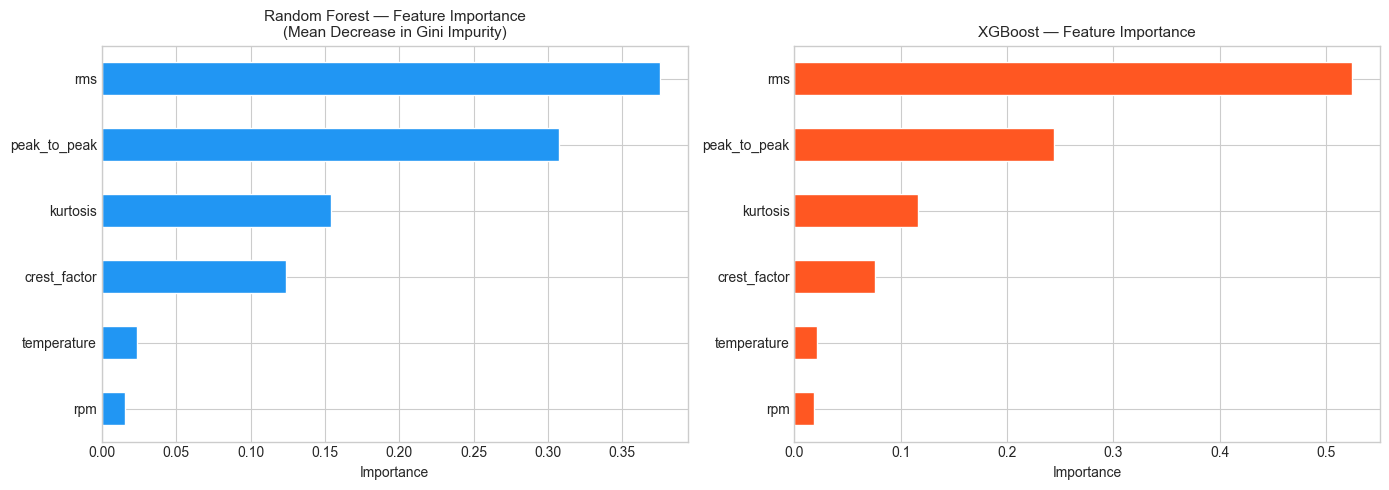

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest importance
rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
rf_importance.plot(kind='barh', ax=ax1, color=PALETTE[0], edgecolor='white')
ax1.set_title('Random Forest — Feature Importance\n(Mean Decrease in Gini Impurity)', fontsize=11)
ax1.set_xlabel('Importance')

# XGB / GBM importance
if hasattr(model, 'feature_importances_'):
    xgb_importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    xgb_importance.plot(kind='barh', ax=ax2, color=PALETTE[1], edgecolor='white')
    ax2.set_title(f'{"XGBoost" if XGB_AVAILABLE else "GradientBoosting"} — Feature Importance', fontsize=11)
    ax2.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('plots/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · SHAP — Shapley Additive Explanations

**SHAP** provides theoretically grounded model-agnostic explanations based on cooperative game theory.  
The Shapley value of feature $j$ for prediction $i$ is:

$$\phi_{ij} = \sum_{S \subseteq \mathcal{F} \setminus \{j\}} \frac{|S|!(p-|S|-1)!}{p!} \left[ f(S \cup \{j\}) - f(S) \right]$$

**Properties guaranteed:**
- **Efficiency**: $\sum_j \phi_{ij} = f(\mathbf{x}_i) - \mathbb{E}[f]$
- **Symmetry**: equal features get equal attribution
- **Null player**: features with no effect get $\phi = 0$

For tree ensembles, SHAP is computed exactly in $O(TLD^2)$ (TreeSHAP algorithm, Lundberg et al., 2020).

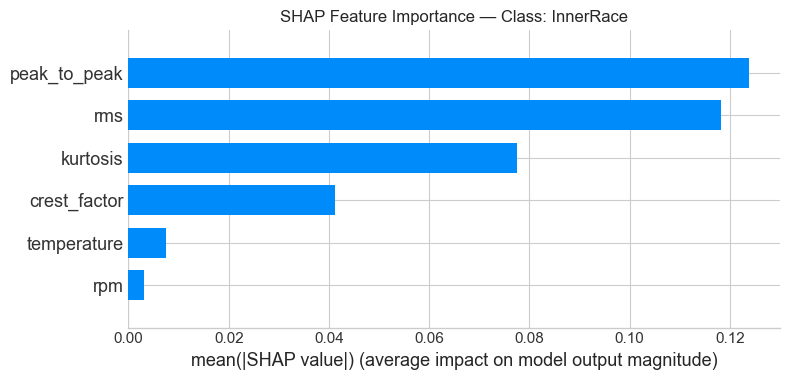

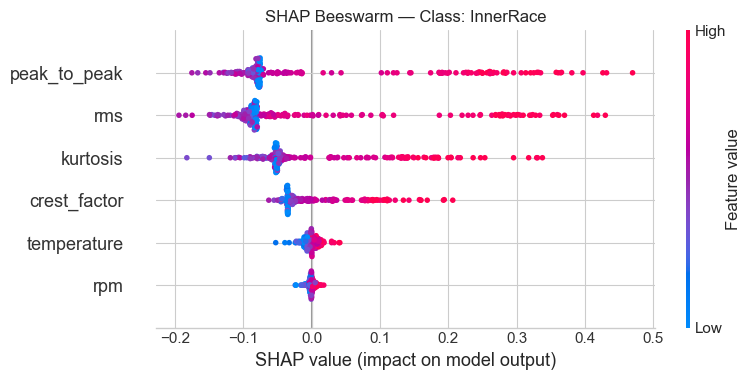

In [8]:
if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test)

    # SHAP 0.50+ returns 3D array (n_samples, n_features, n_classes); older returns list
    class_idx = 1
    if isinstance(shap_values, list):
        sv = shap_values[class_idx]
    else:
        sv = shap_values[:, :, class_idx]

    plt.figure(figsize=(10, 5))
    shap.summary_plot(sv, X_test, feature_names=feature_cols, plot_type='bar', show=False)
    plt.title(f'SHAP Feature Importance — Class: {le.classes_[class_idx]}', fontsize=12)
    plt.tight_layout()
    plt.savefig('plots/05_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Beeswarm plot
    plt.figure(figsize=(10, 5))
    shap.summary_plot(sv, X_test, feature_names=feature_cols, show=False)
    plt.title(f'SHAP Beeswarm — Class: {le.classes_[class_idx]}', fontsize=12)
    plt.tight_layout()
    plt.savefig('plots/05_shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Install SHAP: pip install shap')
    print('\nFallback: Manual permutation importance')
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
    perm_df = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=True)
    perm_df.plot(kind='barh', color=PALETTE[2], edgecolor='white', figsize=(8, 4))
    plt.title('Permutation Importance (SHAP substitute)', fontsize=11)
    plt.savefig('plots/05_permutation_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5 · Model Comparison

Random Forest       : 0.9475 ± 0.0086 (5-fold CV)


XGB / GBM           : 0.9475 ± 0.0033 (5-fold CV)


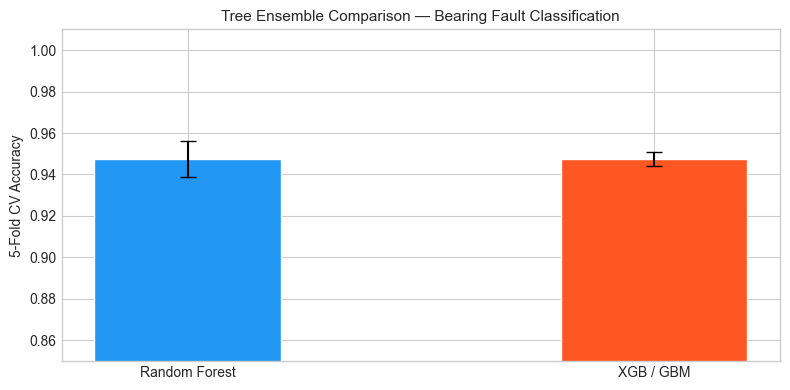

In [9]:
results = {}
models = {
    'Random Forest': rf,
    'XGB / GBM': model,
}
for name, m in models.items():
    cv_scores = cross_val_score(m, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    results[name] = {'mean': cv_scores.mean(), 'std': cv_scores.std()}
    print(f'{name:20s}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} (5-fold CV)')

# Bar chart
names = list(results.keys())
means = [results[n]['mean'] for n in names]
stds  = [results[n]['std']  for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(names, means, yerr=stds, capsize=6, color=PALETTE[:2], edgecolor='white', width=0.4)
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_ylim(0.85, 1.01)
ax.set_title('Tree Ensemble Comparison — Bearing Fault Classification', fontsize=11)
plt.tight_layout()
plt.savefig('plots/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Conclusion

### Why Trees Beat Linear Models on This Data
- **Kurtosis** and **crest factor** are non-linear indicators of impulsive vibration — decision trees capture threshold-like effects naturally.
- **Temperature** interacts with RPM in a non-additive way (heat at high speed ≠ heat at low speed).

### SHAP vs Gini Importance
| Method | Advantage | Limitation |
|--------|-----------|------------|
| Gini importance | Fast, built-in | Biased toward high-cardinality features |
| SHAP | Theoretically grounded, instance-level | Slower (mitigated by TreeSHAP) |

### Industrial Implication (HAIIP context)
In the HAIIP production system, Random Forest predictions are accompanied by SHAP explanations delivered to operators via the Streamlit dashboard — satisfying **EU AI Act Article 13** (transparency) and **Article 14** (human oversight).

→ **Week 4**: Rigorous evaluation — k-fold CV, ROC-AUC, calibration curves.